In [2]:
import os
import time
import itertools
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn                 import datasets
from sklearn.preprocessing   import MinMaxScaler
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.linear_model    import LinearRegression,RidgeCV, Ridge, ElasticNet, ElasticNetCV
from sklearn.metrics         import mean_squared_error, euclidean_distances
from sklearn.linear_model import LinearRegression
from pandas.plotting import autocorrelation_plot

In [3]:
RANDOM_STATE = 24
np.random.seed(RANDOM_STATE) # Set Random Seed for reproducible  results
rnd = np.random.RandomState(RANDOM_STATE)

# NOISE     = 0.1
# N_SAMPLES = 1000
# ALPHA     =0.001
# TEST_SIZE =0.2

params = {'legend.fontsize': 'large',
          'figure.figsize': (15, 5),
          'axes.labelsize': 'large',
          'axes.titlesize':'x-large',
          'xtick.labelsize':'large',
          'ytick.labelsize':'large',
          'savefig.dpi': 75,
          'image.interpolation': 'none',
          'savefig.bbox' : 'tight',
          'lines.linewidth' : 1,
          'legend.numpoints' : 1
         }

CMAP = plt.cm.rainbow
plt.rcParams.update(params);
plt.set_cmap(CMAP);


TEST_SIZE = 0.25

<Figure size 1500x500 with 0 Axes>

In [4]:
data_df=pd.read_csv('quarterly-beer-production-in-aus-March 1956-June 1994.csv')

In [5]:
data_df.columns = ['quarter', 'production']
data_df.head()

,quarter,production
0,1956Q1,284.4
1,1956Q2,212.8
2,1956Q3,226.9
3,1956Q4,308.4
4,1957Q1,262.0


In [6]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154 entries, 0 to 153
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   quarter     154 non-null    object 
 1   production  154 non-null    float64
dtypes: float64(1), object(1)
memory usage: 2.5+ KB


In [7]:
def fn_quater_to_datetime(quarter_str):
    #1956Q1
    year, quarter = quarter_str.split('Q')
    month = np.int16(quarter)*3-2
    return pd.to_datetime(f'{year}-{month:02d}')

In [8]:
data_df['date']= data_df['quarter'].apply(fn_quater_to_datetime)
data_df.head()

,quarter,production,date
0,1956Q1,284.4,1956-01-01
1,1956Q2,212.8,1956-04-01
2,1956Q3,226.9,1956-07-01
3,1956Q4,308.4,1956-10-01
4,1957Q1,262.0,1957-01-01


In [9]:
data_df['date'].dt.year.unique()

array([1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966,
       1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977,
       1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988,
       1989, 1990, 1991, 1992, 1993, 1994])

<Axes: xlabel='date', ylabel='production'>

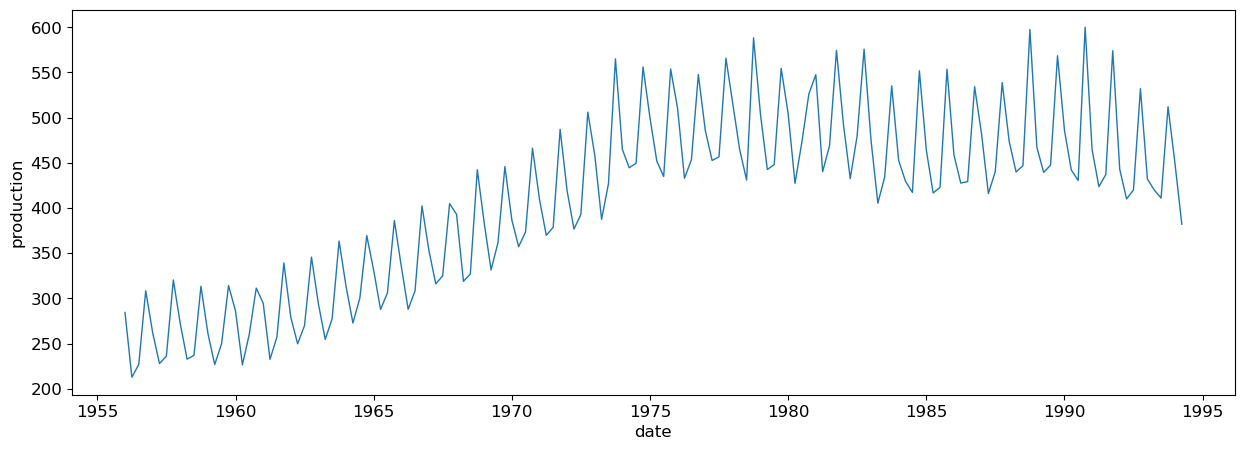

In [10]:
# line plot
sns.lineplot(data=data_df, x='date', y='production')

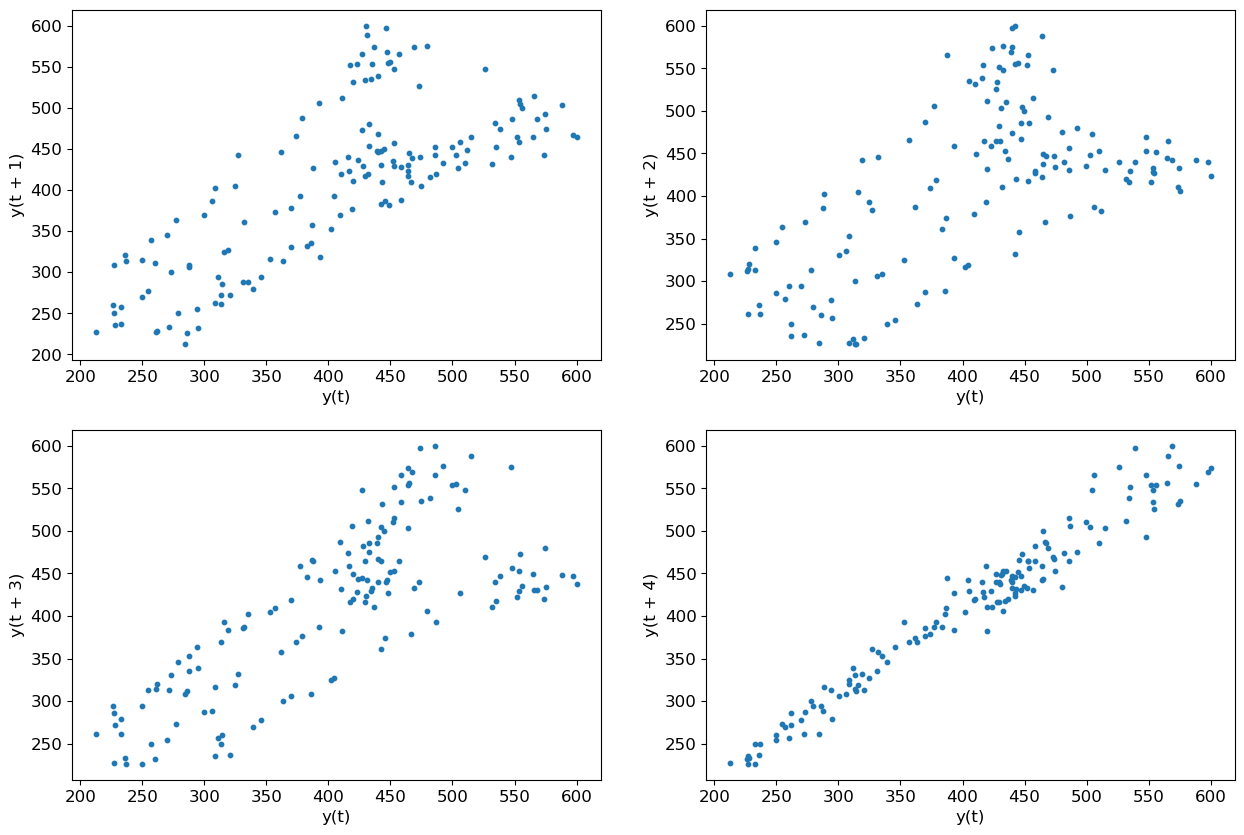

In [11]:
fig, axes = plt.subplots(2,2, figsize=(15,10))

for count, ax in enumerate(axes.ravel()):
    pd.plotting.lag_plot(data_df['production'], lag= count+1, ax=ax, s=10)

In [12]:
lag = np.arange(1,7)
data_acf = []

for l in lag:
    data_acf.append(data_df['production'].autocorr(l))

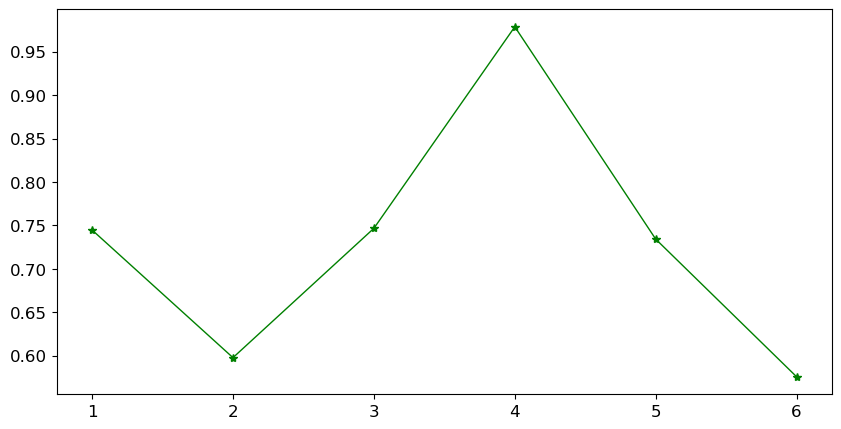

In [13]:
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(lag, data_acf, marker='*', color='g')

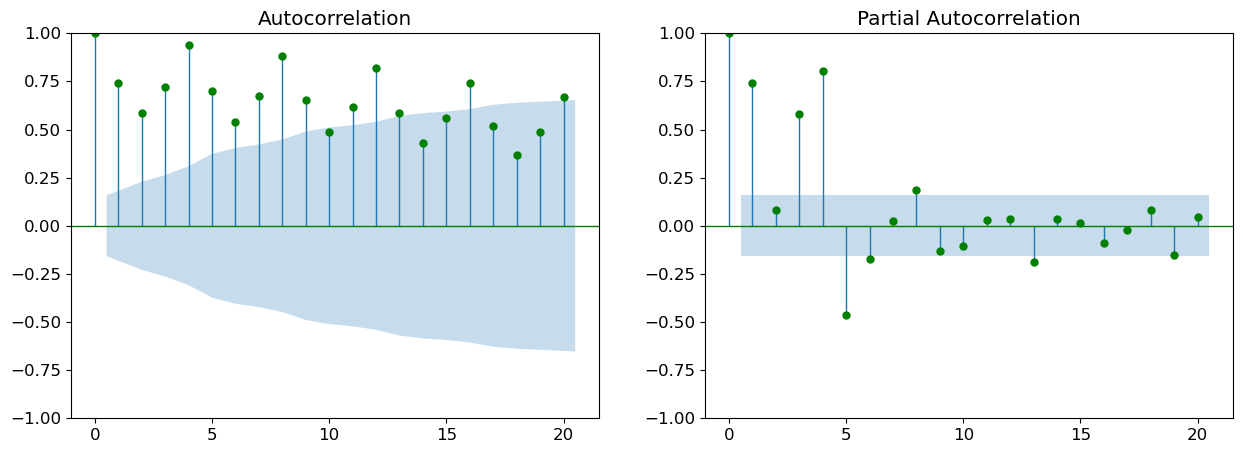

In [14]:
fig, axes = plt.subplots(1,2)
_ = plot_acf(data_df['production'], lags=20, color='g', ax=axes[0])
_ = plot_pacf(data_df['production'], lags=20, color='g', ax=axes[1])

In [15]:
def get_trend(timeseries, deg = 3):

    x = list(range(len(timeseries)))
    y = timeseries.values
    coef = np.polyfit(x,y, deg)
    trend = np.poly1d(coef)(x)
    return pd.Series(data=trend, index = timeseries.index)

In [16]:
data_df['Trend'] = get_trend(data_df['production'])
data_df.head()

,quarter,production,date,Trend
0,1956Q1,284.4,1956-01-01,232.006953
1,1956Q2,212.8,1956-04-01,234.321738
2,1956Q3,226.9,1956-07-01,236.678431
3,1956Q4,308.4,1956-10-01,239.075917
4,1957Q1,262.0,1957-01-01,241.513080


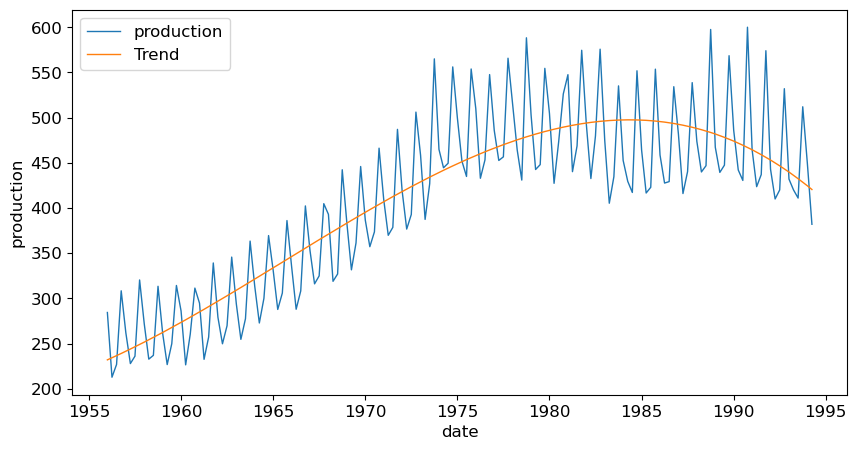

In [17]:
fig, ax = plt.subplots(figsize=(10,5))

sns.lineplot(data=data_df, x='date', y='production', label = 'production', ax = ax)
sns.lineplot(data=data_df, x='date', y='Trend', label = 'Trend', ax = ax);

In [18]:
data_df['year'] = data_df['date'].dt.year
data_df['month'] = data_df['date'].dt.month
data_df.head()

,quarter,production,date,Trend,year,month
0,1956Q1,284.4,1956-01-01,232.006953,1956,1
1,1956Q2,212.8,1956-04-01,234.321738,1956,4
2,1956Q3,226.9,1956-07-01,236.678431,1956,7
3,1956Q4,308.4,1956-10-01,239.075917,1956,10
4,1957Q1,262.0,1957-01-01,241.513080,1957,1


Text(0.5, 0, 'Months')

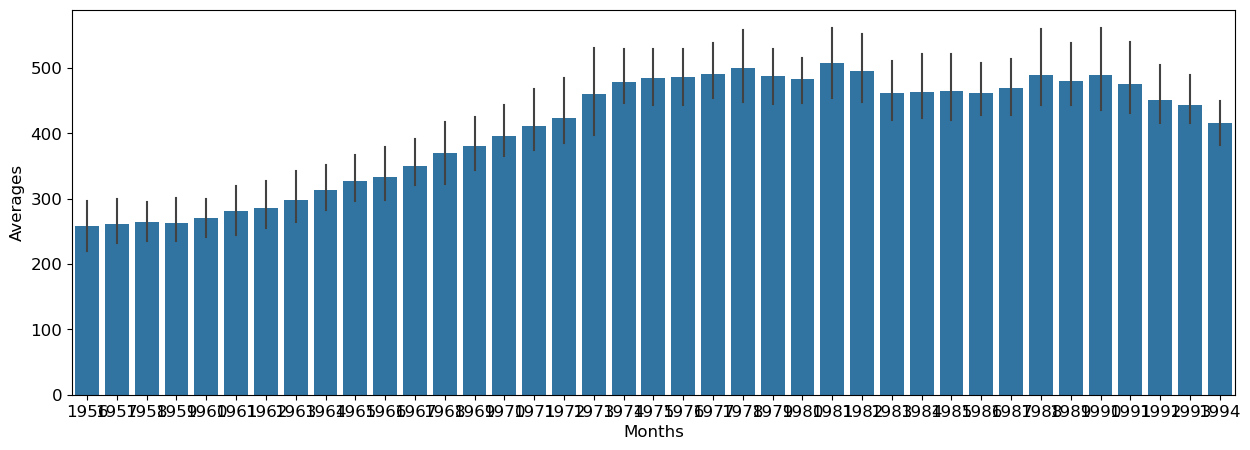

In [19]:
plt.figure()

bar = sns.barplot(data=data_df, x = 'year', y = 'production')
bar.set_ylabel('Averages')
bar.set_xlabel('Months')

Text(0.5, 0, 'years')

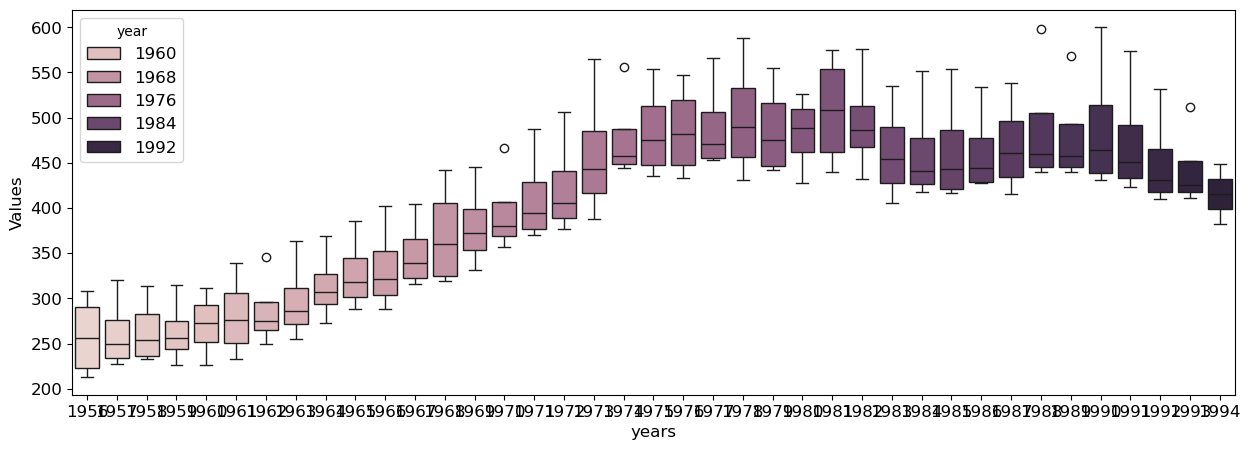

In [20]:
plt.figure()
bar = sns.boxplot(data=data_df, x = 'year', y = 'production', hue='year')
bar.set_ylabel('Values')
bar.set_xlabel('years')

Text(0.5, 0, 'years')

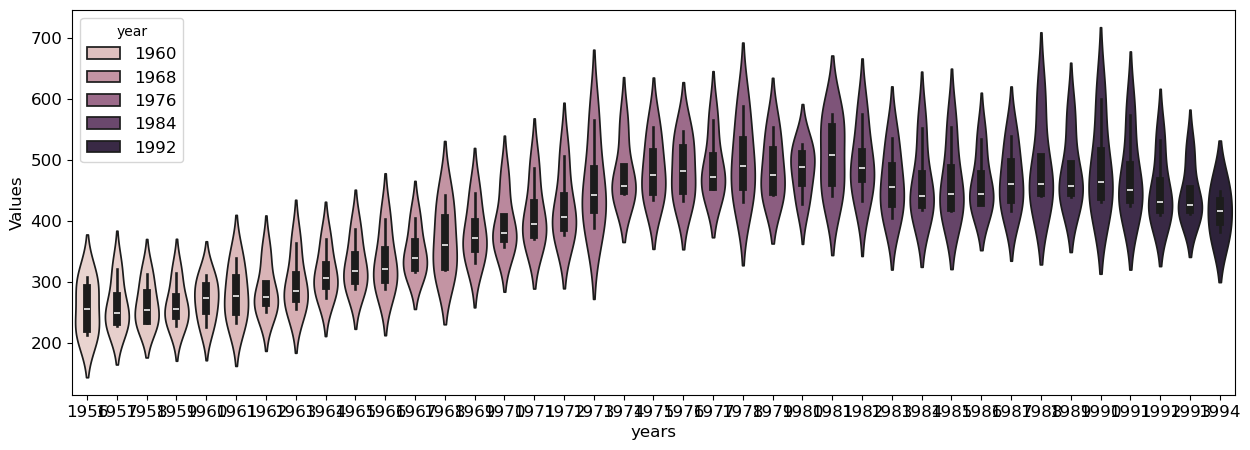

In [21]:
plt.figure()
bar = sns.violinplot(data=data_df, x = 'year', y = 'production', hue='year')
bar.set_ylabel('Values')
bar.set_xlabel('years')

Text(0.5, 0, 'months')

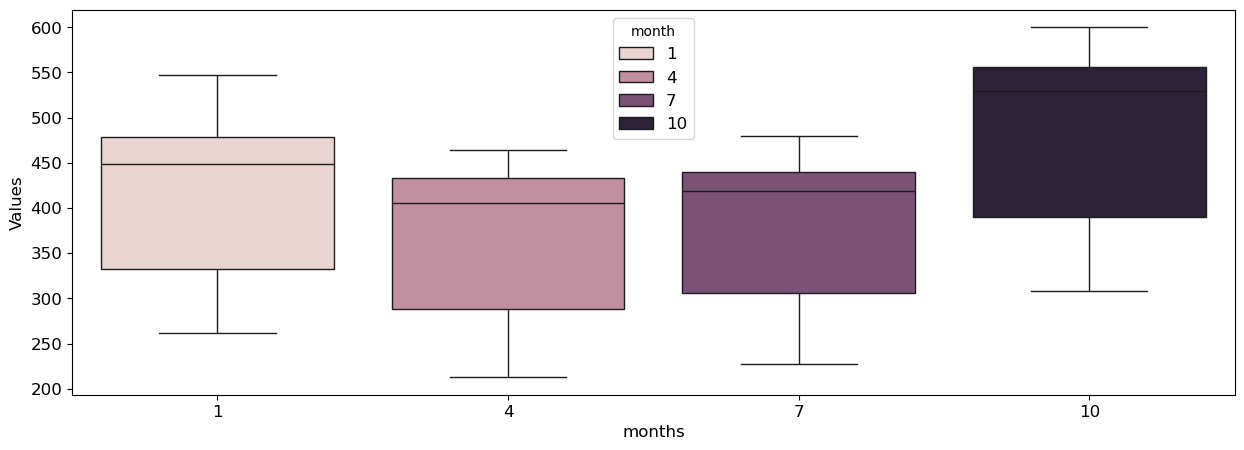

In [22]:
plt.figure()
bar = sns.boxplot(data=data_df, x = 'month', y = 'production', hue='month')
bar.set_ylabel('Values')
bar.set_xlabel('months')

Text(0.5, 0, 'months')

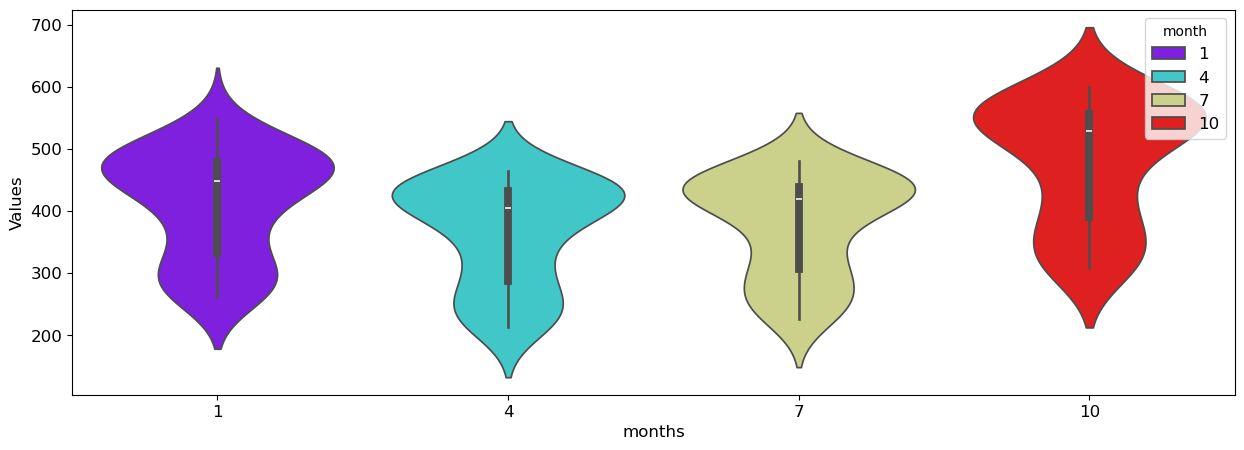

In [23]:
plt.figure()
bar = sns.violinplot(data=data_df, x = 'month', y = 'production', hue='month', palette=CMAP)
bar.set_ylabel('Values')
bar.set_xlabel('months')

In [34]:
feature_df = data_df[['production']].copy()

feature_df.columns = [' T_i' ] #columnrenamed
feature_df [' T_(i-1)' ]= feature_df['T_i'].shift(1)
feature_df [' T_(i-2)' ]= feature_df['T_i'].shift(2)
feature_df.head()

KeyError: 'T_i'

In [ ]:
decomposition = sm.tsa.seasonal_decompose(data_df['production'], model = 'additive', period = 12)
fig = decomposition.plot()
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

dftest = adfuller(data_df[['production']], autolag='AIC')

dfoutput = pd.Series(dftest[:4], index = ['Test Statics', 'p-value', '#Lag', '# of Observations'])

In [ ]:
for key, value in dftest[4].items():
    dfoutput[f'Critical values {key}'] = value
dfoutput

In [ ]:
month_df = data_df.set_index('date')
display(month_df.head())
ts_log = np.log(month_df['production'])  
plt.plot(ts_log)

In [ ]:
dftest = adfuller(ts_log, autolag='AIC')

dfoutput = pd.Series(dftest[:4], index = ['Test Statics', 'p-value', '#Lag', '# of Observations'])

for key, value in dftest[4].items():
    dfoutput[f'Critical values {key}'] = value
dfoutput

In [ ]:
moving_avg = ts_log.rolling(12).mean()

plt.plot(ts_log)
plt.plot(moving_avg, color = 'g', lw=3)

In [ ]:
ts_log_av = ts_log-moving_avg
ts_log_av.dropna(inplace=True)

dftest = adfuller(ts_log_av, autolag='AIC')

dfoutput = pd.Series(dftest[:4], index = ['Test Statics', 'p-value', '#Lag', '# of Observations'])

for key, value in dftest[4].items():
    dfoutput[f'Critical values {key}'] = value
dfoutput

In [ ]:
plt.plot(ts_log)
plt.plot(moving_avg, color='g', lw=3)
plt.plot(ts_log_av, color='r')